Nombre: Vicente Arechavala Alegría

Curso: Introducción a la inteligencia artificial

Profesor: Gabriel Cabas

### Librerias + Base de datos

In [1]:
#Librerias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#Subida de base de datos
data = pd.read_csv("laliga.csv") 

data

,League,Date,HomeTeam,AwayTeam,HomeGoals,AwayGoals,Result
0,La Liga,05/09/93,Ath Bilbao,Albacete,4.0,1.0,H
1,La Liga,05/09/93,Ath Madrid,Logrones,1.0,0.0,H
2,La Liga,05/09/93,Barcelona,Sociedad,3.0,0.0,H
3,La Liga,05/09/93,La Coruna,Celta,0.0,0.0,D
4,La Liga,05/09/93,Osasuna,Real Madrid,1.0,4.0,A
...,...,...,...,...,...,...,...
11559,La Liga,04/06/2023,Betis,Valencia,1.0,1.0,D
11560,La Liga,04/06/2023,Celta,Barcelona,2.0,1.0,H
11561,La Liga,04/06/2023,Elche,Cadiz,1.0,1.0,D
11562,La Liga,04/06/2023,Espanol,Almeria,3.0,3.0,D


La base cuenta con los datos de todos los partidos de la primera división de España desde el año 1993 hasta 2023, exponiendo resultados de victoria para el equipo local (H), victoria para el visitante (A) y empate (D).


### Chequeo de la base 

In [2]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11564 entries, 0 to 11563
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   League     11564 non-null  object 
 1   Date       11564 non-null  object 
 2   HomeTeam   11564 non-null  object 
 3   AwayTeam   11564 non-null  object 
 4   HomeGoals  11564 non-null  float64
 5   AwayGoals  11564 non-null  float64
 6   Result     11564 non-null  object 
dtypes: float64(2), object(5)
memory usage: 632.5+ KB


Como se observa, la base de datos al registrar resultados de todos los partidos no cuenta con datos nulos.

### Distribución de los resultados

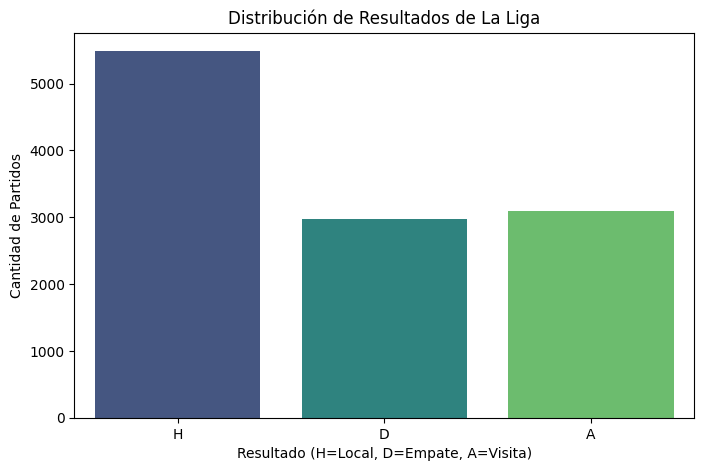

In [3]:
plt.figure(figsize=(8, 5))
sns.countplot(data=data, x='Result', hue='Result', palette='viridis', legend=False)
plt.title('Distribución de Resultados de La Liga')
plt.xlabel('Resultado (H=Local, D=Empate, A=Visita)')
plt.ylabel('Cantidad de Partidos')
plt.show()

Se puede observar primeramente que la localía del equipo es un dato relevante para lograr la victoria. Sin embargo, al ser esto una generalidad, sería conveniente determinar si dicha generalidad presenta algún tipo de cambio respecto al tiempo o a un equipo en concreto.

### Distribución de victorias como local según la década

C:\Users\Vicen\AppData\Local\Temp\ipykernel_16092\3974075700.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data['Date'] = pd.to_datetime(data['Date'], dayfirst=True)


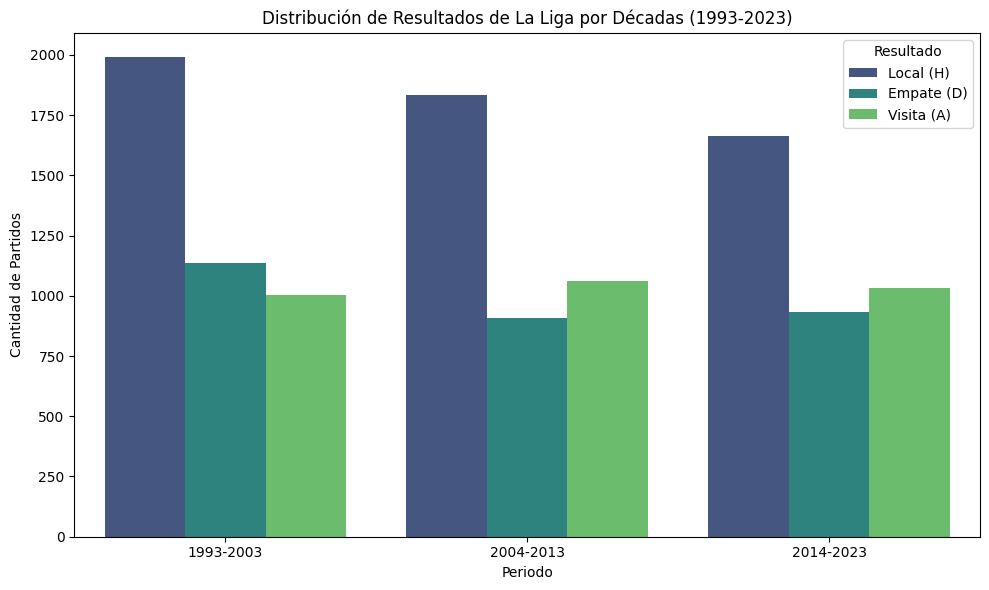

In [4]:
data['Date'] = pd.to_datetime(data['Date'], dayfirst=True)

data['Year'] = data['Date'].dt.year

def decada(year):
    if 1993 <= year <= 2003:
        return '1993-2003'
    elif 2004 <= year <= 2013:
        return '2004-2013'
    elif 2014 <= year <= 2023:
        return '2014-2023'
    else:
        return 'Fuera de rango'

data['Periodo'] = data['Year'].apply(decada)

plt.figure(figsize=(10, 6))
ax = sns.countplot(data=data, 
                   x='Periodo', 
                   hue='Result', 
                   palette='viridis', 
                   order=['1993-2003', '2004-2013', '2014-2023'],
                   hue_order=['H', 'D', 'A']) # Asegura el orden Local, Empate, Visita

plt.title('Distribución de Resultados de La Liga por Décadas (1993-2023)')
plt.xlabel('Periodo')
plt.ylabel('Cantidad de Partidos')
plt.legend(title='Resultado', labels=['Local (H)', 'Empate (D)', 'Visita (A)'])
plt.tight_layout()
plt.show()

Como se observa, en la primera década existe una mayor diferencia en los resultados, puesto que la capacidad de conseguir de la victoria por parte del equipo local empieza a descender ligeramente en las siguientes décadas de la base de datos. Pero, para confirmar la tendencia observada en el gráfico anterior, se calculará el porcentaje de victorias locales sobre el total de partidos de cada periodo. Esto permite ver con mayor precisión si la ventaja de local realmente disminuye con el tiempo, más allá de lo que sugiere la inspección visual del gráfico de barras.

### Tasa de victorias según década

Periodo
1993-2003    48.2
2004-2013    48.2
2014-2023    45.8
Name: Result, dtype: float64


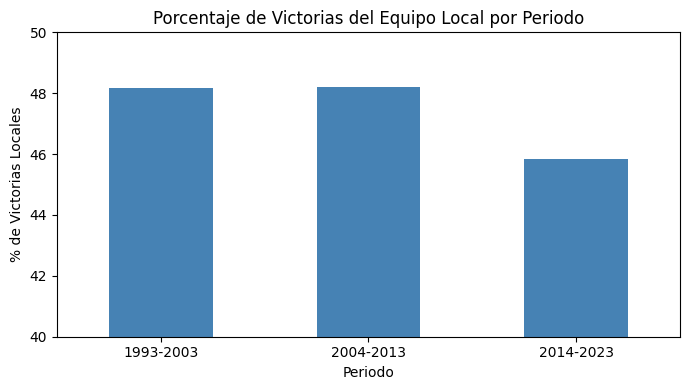

In [5]:
# Cuantificamos la ventaja de jugar de local: % de victorias H sobre el total de partidos, por periodo
porcentaje_local = (
    data.groupby('Periodo')['Result']
    .apply(lambda x: (x == 'H').mean() * 100)
    .reindex(['1993-2003', '2004-2013', '2014-2023'])
)

print(porcentaje_local.round(1))

plt.figure(figsize=(7, 4))
porcentaje_local.plot(kind='bar', color='steelblue')
plt.title('Porcentaje de Victorias del Equipo Local por Periodo')
plt.xlabel('Periodo')
plt.ylabel('% de Victorias Locales')
plt.ylim(40, 50)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


Por medio de este gráfico, se confirma que exite un distinto porcentaje de victorias hacia el equipo local dependiendo de la década que estemos observando.

### Mayor y menor cantidad de victorias por equipo

In [6]:
victorias_local = data[data['Result'] == 'H']['HomeTeam'].value_counts()
partidos_local = data['HomeTeam'].value_counts()
tasa_victorias_local = (victorias_local / partidos_local * 100).dropna().sort_values(ascending=False)

print("Top 5 por % de victorias de local:\n", tasa_victorias_local.head(5))
print("\nPeores 5 por % de victorias de local:\n", tasa_victorias_local.tail(5))

Top 5 por % de victorias de local:
 HomeTeam
Barcelona      75.261324
Real Madrid    73.519164
Ath Madrid     60.261194
Valencia       55.749129
Sevilla        55.319149
Name: count, dtype: float64

Peores 5 por % de victorias de local:
 HomeTeam
Cadiz        25.000000
Logrones     22.033898
Gimnastic    21.052632
Lerida       15.789474
Cordoba       5.263158
Name: count, dtype: float64


Como se puede ver en los datos, existe diferentes capacidades de victoria dependiendo del equipo, lo que probablemente tenga que ver con el presupuesto del equipo en si. Más allá de eso, es importante recalcar que las tasas de equipos más bajos pueden tener relación con equipos que disputaron una menor cantidad de ligas (entiendase por esto que existe el descenso para los 3 equipos con el menor rendimiento). Por lo tanto, sería importante apreciar si es que esta tendencia también se aplica para equipos que hayan tenido una importante cantidad de temporadas en la primera división de España.

### Comparativa de equipos con una alta participación en la primera liga de España

Nota: Para la elección de los equipos se buscó por internet cuales son los equipos que han tenido mayor presencia a lo largo de estos 30 años, dando como resultado los 5 equipos elegidos abajo.

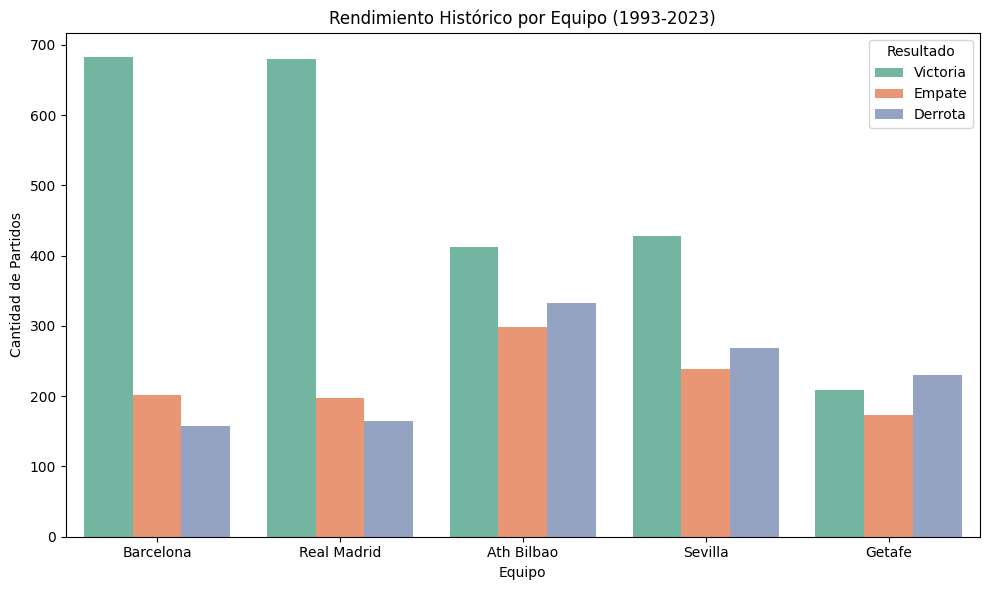

In [7]:
equipos = ['Barcelona', 'Real Madrid', 'Ath Bilbao', 'Sevilla', 'Getafe']
data_equipos = data[(data['HomeTeam'].isin(equipos)) | (data['AwayTeam'].isin(equipos))].copy()

def resultado_y_equipo(fila, equipos):
    if fila['HomeTeam'] in equipos:
        equipo = fila['HomeTeam']
        if fila['Result'] == 'H': return pd.Series([equipo, 'Victoria'])
        elif fila['Result'] == 'D': return pd.Series([equipo, 'Empate'])
        elif fila['Result'] == 'A': return pd.Series([equipo, 'Derrota'])
    elif fila['AwayTeam'] in equipos:
        equipo = fila['AwayTeam']
        if fila['Result'] == 'A': return pd.Series([equipo, 'Victoria'])
        elif fila['Result'] == 'D': return pd.Series([equipo, 'Empate'])
        elif fila['Result'] == 'H': return pd.Series([equipo, 'Derrota'])

data_equipos[['Equipo', 'Desempeño']] = data_equipos.apply(
    lambda fila: resultado_y_equipo(fila, equipos), axis=1
)

# --- 3. GRAFICAR: conteo agrupado por equipo ---
plt.figure(figsize=(10, 6))
sns.countplot(data=data_equipos,
              x='Equipo',
              hue='Desempeño',
              hue_order=['Victoria', 'Empate', 'Derrota'],
              order=equipos,
              palette='Set2')

plt.title('Rendimiento Histórico por Equipo (1993-2023)')
plt.xlabel('Equipo')
plt.ylabel('Cantidad de Partidos')
plt.legend(title='Resultado')
plt.tight_layout()
plt.show()

Dado lo visto previamente, se denota que equipos como el Barcelona o Real Madrid tienen un desbalance estadístico masivo a su favor. Este sesgo es algo a tener en cuenta más adelante, cuando se trabaje en la etapa de modelado predictivo, ya que podría influir en que el modelo tienda a favorecer siempre a estos equipos cuando juegan de local.

### Mapa de calor de algunos equipos de la Liga

Nota: Nuevamente se utilizó la busqueda en internet para buscar estos equipos.

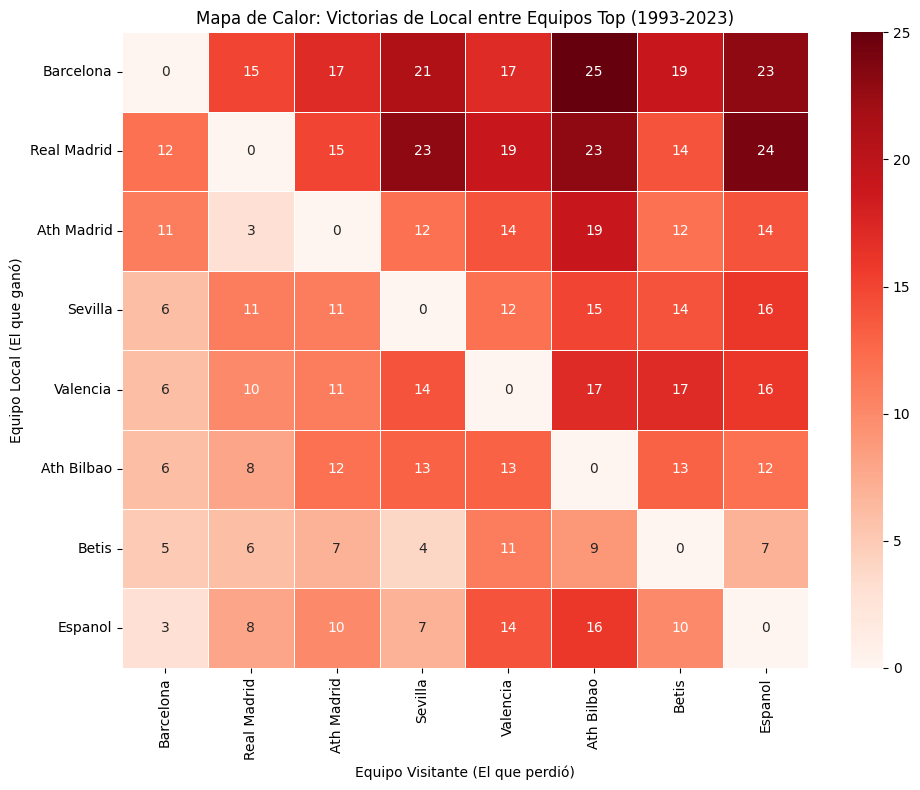

In [8]:
equipos_2 = ['Barcelona', 'Real Madrid', 'Ath Madrid', 'Sevilla', 'Valencia','Ath Bilbao', 'Betis', 'Espanol']
data_equipos_2 = data[(data['HomeTeam'].isin(equipos_2)) & (data['AwayTeam'].isin(equipos_2))]
data_victorias = data_equipos_2[data_equipos_2['Result'] == 'H']

matriz_enfrentamientos = pd.crosstab(data_victorias['HomeTeam'], data_victorias['AwayTeam'])
matriz_enfrentamientos = matriz_enfrentamientos.reindex(index=equipos_2, columns=equipos_2, fill_value=0)

plt.figure(figsize=(10, 8))
sns.heatmap(matriz_enfrentamientos, annot=True, cmap='Reds', fmt='d', linewidths=.5)
plt.title('Mapa de Calor: Victorias de Local entre Equipos Top (1993-2023)')
plt.xlabel('Equipo Visitante (El que perdió)')
plt.ylabel('Equipo Local (El que ganó)')
plt.tight_layout()
plt.show()

Como se puede analizar, efectivamente existen equipos que pueden presentar una "dominancia" respecto de otros equipos. Esto, como ya se indicó previamente, podría ocurrir por cuestiones más relacionadas al presupuesto o calidad de la plantilla, pero es importante que el modelo predictivo que se pretende crear tenga en cuenta dichas ventajas para no subestimar (o sobreestimar) ciertos equipos.

Conclusiones iniciales

En esta primera etapa se realizó una exploración general de la base de datos de La Liga, en donde se puede destacar:

- La base de datos no presenta valores nulos, no se necesitó limpieza adicional en esta etapa.
- Existen ventaja histórica clara para los locales, aunque muestra una leve tendencia a la baja.
- A nivel individual, el rendimiento varía fuertemente, pues equipos como Barcelona y Real Madrid muestran un desbalance estadístico a su favor, lo que es importante considerar para los sesgos.
- El análisis de victorias locales puede mostrar qué enfrentamientos muestran mayor dominancia.

Estos resultados sientan la base exploratoria para la siguiente etapa del proyecto, en la que se buscará construir un modelo predictivo de resultados.

### Modelamiento 

In [9]:
#Librerías
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score, classification_report

In [10]:
data = data.sort_values('Date').reset_index(drop=True)

features = ['HomeTeam', 'AwayTeam']

X_train, X_test, y_train, y_test = train_test_split(
    data[features], data['Result'], test_size=0.2, shuffle=False)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((9251, 2), (2313, 2), (9251,), (2313,))

In [11]:
encoder = OneHotEncoder(handle_unknown='ignore') #Ignora los datos de test que no están en train
X_train = encoder.fit_transform(X_train)
X_test = encoder.transform(X_test)

modelos = {
    'Regresión Logística': LogisticRegression(max_iter=1000),
    'Random Forest': RandomForestClassifier(random_state=42)
}

for nombre, modelo in modelos.items():
    modelo.fit(X_train, y_train)
    pred = modelo.predict(X_test)
    print(f'--- {nombre}')
    print('Accuracy:', round(accuracy_score(y_test, pred), 3))
    print('F1 macro:', round(f1_score(y_test, pred, average='macro'), 3))
    print(classification_report(y_test, pred))
    print()

--- Regresión Logística
Accuracy: 0.495
F1 macro: 0.366
              precision    recall  f1-score   support

           A       0.48      0.35      0.40       653
           D       0.32      0.03      0.06       619
           H       0.51      0.86      0.64      1041

    accuracy                           0.50      2313
   macro avg       0.43      0.41      0.37      2313
weighted avg       0.45      0.50      0.42      2313


--- Random Forest
Accuracy: 0.471
F1 macro: 0.399
              precision    recall  f1-score   support

           A       0.43      0.35      0.39       653
           D       0.32      0.15      0.20       619
           H       0.52      0.74      0.61      1041

    accuracy                           0.47      2313
   macro avg       0.42      0.41      0.40      2313
weighted avg       0.44      0.47      0.44      2313




Como se puede observar en los resultados obtenidos, los modelos cuentan con resultados similares en su acuraccy, siendo ligeramente superior la Regresión Logística. Por otro lado, el F1 macro de Random Forest es superior al de Regresión Logistica, lo que se demuestra en su leve mejoría en la clasificación de los empates.

En ambos modelos se presenta una complejidad enorme en clasificar los empates, además de concentrarse la mayor parte de las predicciones (sesgo) hacia la victoria local (H).

Dicha cuestión probablemente ocurra por lo visto previamente en el data set, el cual presenta un desbalance inclinado hacia las victorias del equipo. Por lo mismo, una manera de balancear este dataset, y al mismo tiempo, mejorar el modelo predictivo es combinando los resultados de empate y derrota, de forma que el modelo solo tenga que elegir entre dos opciones en vez de dos. Si bien es cierto que dicho cambio deshabilita la opción de clasificar un empate, es posible que el porcentaje de acierto generalizado del modelo mejore considerablemente.

### Prueba de balance de datos

In [12]:
data['Victoria_Local'] = (data['Result'] == 'H').astype(int)
data['Victoria_Local'].value_counts()

Victoria_Local
0    6076
1    5488
Name: count, dtype: int64

In [13]:
data = data.sort_values('Date').reset_index(drop=True)

features = ['HomeTeam', 'AwayTeam']

X_train, X_test, y_train, y_test = train_test_split(
    data[features], data['Victoria_Local'], test_size=0.2, shuffle=False)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((9251, 2), (2313, 2), (9251,), (2313,))

In [14]:
encoder = OneHotEncoder(handle_unknown='ignore') #Ignora los datos de test que no están en train
X_train = encoder.fit_transform(X_train)
X_test = encoder.transform(X_test)

modelos = {
    'Regresión Logística': LogisticRegression(max_iter=1000),
    'Random Forest': RandomForestClassifier(random_state=42)
}

for nombre, modelo in modelos.items():
    modelo.fit(X_train, y_train)
    pred = modelo.predict(X_test)
    print(f'--- {nombre}')
    print('Accuracy:', round(accuracy_score(y_test, pred), 3))
    print(classification_report(y_test, pred))
    print()

--- Regresión Logística
Accuracy: 0.622
              precision    recall  f1-score   support

           0       0.65      0.68      0.66      1272
           1       0.58      0.55      0.57      1041

    accuracy                           0.62      2313
   macro avg       0.62      0.62      0.62      2313
weighted avg       0.62      0.62      0.62      2313


--- Random Forest
Accuracy: 0.594
              precision    recall  f1-score   support

           0       0.63      0.63      0.63      1272
           1       0.55      0.54      0.55      1041

    accuracy                           0.59      2313
   macro avg       0.59      0.59      0.59      2313
weighted avg       0.59      0.59      0.59      2313




Se observa que, luego de cambiar el problema de uno multiclase a uno binario, la precision de ambos modelos mejora bastante, pues pasa de un 0.471 a un 0.594 en Random Forest, y de un 0.495 a un 0.622 en Regresión Logística, siendo ahora el mejor modelo. Esto ocurre debido a que, al tratarse ahora de solo dos variables, encuentra la linealidad de los resultados, y por ende, mejora considerablemente su capacidad de predicción. 

#### Nuevas variables

In [15]:
#Racha de victorias del equipo
data = data.sort_values('Date').reset_index(drop=True)

#Se realiza la definición de los puntos obtenidos, pues si es H son 3 puntos para el equipo local y
#0 para el visitante y viceversa. En caso de empate, se le da a ambos equipos 1. 
def resultados_partido(df):
    filas = []
    for _, fila in df.iterrows():
        if fila['Result'] == 'H':
            pts_home, pts_away = 3, 0
        elif fila['Result'] == 'A':
            pts_home, pts_away = 0, 3
        else:
            pts_home, pts_away = 1, 1
        filas.append({'Date': fila['Date'], 'Team': fila['HomeTeam'], 'Puntos': pts_home})
        filas.append({'Date': fila['Date'], 'Team': fila['AwayTeam'], 'Puntos': pts_away})
    return pd.DataFrame(filas)
resultados = resultados_partido(data).sort_values(['Team', 'Date']).reset_index(drop=True)

N = 5 #Ultimos 5 partidos

#Se agrupan las rachas de puntos
resultados['Racha_Puntos'] = (
    resultados.groupby('Team')['Puntos']
    .transform(lambda x: x.shift(1).rolling(N, min_periods=1).mean())
)

#Se agrupan las tasas de victorias
resultados['Victoria'] = (resultados['Puntos'] == 3).astype(int)
resultados['Tasa_Victorias'] = (
    resultados.groupby('Team')['Victoria']
    .transform(lambda x: x.shift(1).expanding(min_periods=1).mean())
)

In [16]:
datos = ['Date', 'Team', 'Racha_Puntos', 'Tasa_Victorias']

data = data.merge(resultados[datos], left_on=['Date', 'HomeTeam'], right_on=['Date', 'Team'], how='left')
data = data.rename(columns={'Racha_Puntos': 'Racha_Puntos_Local', 'Tasa_Victorias': 'Tasa_Victorias_Local'}).drop(columns='Team')

data = data.merge(resultados[datos], left_on=['Date', 'AwayTeam'], right_on=['Date', 'Team'], how='left')
data = data.rename(columns={'Racha_Puntos': 'Racha_Puntos_Visita', 'Tasa_Victorias': 'Tasa_Victorias_Visita'}).drop(columns='Team')

data['Racha_Puntos_Local'] = data['Racha_Puntos_Local'].fillna(data['Racha_Puntos_Local'].mean())
data['Racha_Puntos_Visita'] = data['Racha_Puntos_Visita'].fillna(data['Racha_Puntos_Visita'].mean())
data['Tasa_Victorias_Local'] = data['Tasa_Victorias_Local'].fillna(0.5)
data['Tasa_Victorias_Visita'] = data['Tasa_Victorias_Visita'].fillna(0.5)
print(data.isnull().sum())


League                   0
Date                     0
HomeTeam                 0
AwayTeam                 0
HomeGoals                0
AwayGoals                0
Result                   0
Year                     0
Periodo                  0
Victoria_Local           0
Racha_Puntos_Local       0
Tasa_Victorias_Local     0
Racha_Puntos_Visita      0
Tasa_Victorias_Visita    0
dtype: int64


In [17]:
info_equipos = ['HomeTeam', 'AwayTeam']
stats_equipos = ['Racha_Puntos_Local', 'Tasa_Victorias_Local', 'Racha_Puntos_Visita', 'Tasa_Victorias_Visita']

X = data[info_equipos + stats_equipos]
y = data['Victoria_Local']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((9251, 6), (2313, 6), (9251,), (2313,))

In [24]:
pred = ColumnTransformer([
    ('info', OneHotEncoder(handle_unknown='ignore'), info_equipos),
    ('stats', StandardScaler(), stats_equipos)
])

pipeline = Pipeline([
    ('pred', pred),
    ('modelo', RandomForestClassifier(random_state=42, max_depth=8, min_samples_leaf=10, n_estimators=200))
])
pipeline.fit(X_train, y_train)

,steps,"[('pred', ...), ('modelo', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('info', ...), ('stats', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


              precision    recall  f1-score   support

           0       0.64      0.78      0.70      1272
           1       0.63      0.46      0.53      1041

    accuracy                           0.64      2313
   macro avg       0.64      0.62      0.62      2313
weighted avg       0.64      0.64      0.63      2313



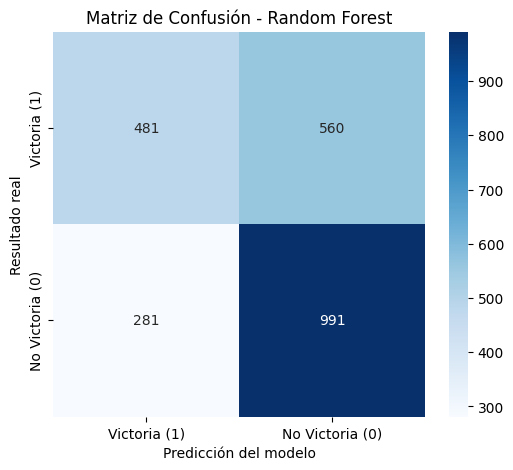

In [25]:
pred_train = pipeline.predict(X_train)
pred_test = pipeline.predict(X_test)

print(classification_report(y_test, pred_test))

matriz = confusion_matrix(y_test, pred_test, labels=[1, 0])
plt.figure(figsize=(6, 5))
sns.heatmap(matriz, annot=True, fmt='d', cmap='Blues',
xticklabels=['Victoria (1)', 'No Victoria (0)'],
            yticklabels=['Victoria (1)', 'No Victoria (0)'])
plt.title('Matriz de Confusión - Random Forest')
plt.xlabel('Predicción del modelo')
plt.ylabel('Resultado real')
plt.show()